<a href="https://colab.research.google.com/github/thofaa/cosine_similarity/blob/main/cosine_tf_idf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TF-IDF (Term Frequency - Inverse Document Frequency)**


---


1. TF (Term Frequency) -> how often the word occurs in a document/text/article. If a word is often occur in a document, the importance of the word will be rise.

    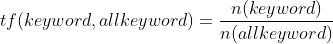

2. IDF (Inverse Document Frequency) -> Make a rare word in a document has a high weight rather than word that often occurs in a document.

    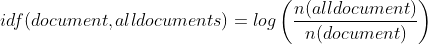

  - when the n(document) is same with n(alldocument) and the value of IDF will be zero, this will make the weight of the keyword will be zero also. This means that the keyword always occurs in every sentence and can be possibly considered to be stopword.
  
  - and otherwise if n(document) is zero value, this means that there is a weight that will be displayed because the keyword itself is not occured in all of the sentences. This can be considered the weight is also zero.

  3. TF-IDF -> the product between TF and IDF will result TF-IDF value


In [ ]:
import numpy as np

class vectorization:

    def __init__(self):
        self.vector = [] #vector that contain the counting of each keyword in the all sentences

    def initial_vectorization(self, *texts):
        self.index = {}
        self.uniquekeywords = set()

        allkeywords = [] #all keywords that contains in all sentences
        for text in texts:
          keywords = text.lower().split() #separate string object based on the whitespace (in list form)
          allkeywords.append(keywords)
          self.uniquekeywords.update(set(keywords)) #set is unordered and only stored unique char

        numberindex=0
        for keyword in self.uniquekeywords:
            self.index[f'{keyword}']=numberindex
            numberindex+=1

        for row in range(len(texts)):
            tempvector = []
            for keyword,value in self.index.items():
              numberword = 0
              for el in allkeywords[row]:
                if el == keyword:
                  numberword += 1
              tempvector.append(numberword)
            self.vector.append(tempvector)

    def cosine_similarity(self, text1, text2):
      v1=np.array(self.vector[int(text1)])
      v2=np.array(self.vector[int(text2)])
      dotprod = v1.dot(v2)
      magnitudeprod = np.sqrt(sum(v1**2))*np.sqrt(sum(v2**2))
      if magnitudeprod == 0:
        self.cosvalue = 0.0
      self.cosvalue = dotprod/magnitudeprod

    def tf_idf(self):
      self.all_tf_idf = {}
      self.dict_tf_val = {}
      self.dict_idf_val = {}

      #counting if and idf separately
      for key, value in self.index.items():
        for row in range(len(self.vector)):
          tfval = self.vector[row][value]/sum(self.vector[row])
          if key not in self.dict_tf_val:
            self.dict_tf_val[key] = [tfval]
          else:
            self.dict_tf_val[key].append(tfval)

        idfval = np.log10(len(self.vector)/np.count_nonzero(self.dict_tf_val[key]))
        self.dict_idf_val[key] = idfval

      #counting if-idf product
      for key, value in self.dict_tf_val.items():
        tf_idf_val = np.array(value)*self.dict_idf_val[key]
        self.all_tf_idf[key] = tf_idf_val

    def weight_vectorization(self):
      self.weight_vector = []

      for column in range(len(self.vector)):
        tempweightvector = []
        for key, value in self.all_tf_idf.items():
          tempweightvector.append(value[column])
        self.weight_vector.append(tempweightvector)

    def weight_cosine_similarity(self, text1, text2):
      v1=np.array(self.weight_vector[int(text1)])
      v2=np.array(self.weight_vector[int(text2)])
      dotprod = v1.dot(v2)
      magnitudeprod = np.sqrt(sum(v1**2))*np.sqrt(sum(v2**2))
      if magnitudeprod == 0:
        self.weight_cosvalue = 0.0
      else:
        self.weight_cosvalue = dotprod/magnitudeprod

In [ ]:
import numpy as np
import pandas as pd

def correlation_matrix(vectorizer_instance, valtype):
    valtype1 = 'cosine_similarity'
    valtype2 = 'weight_cosine_similarity'

    #checking attribute error with hasattr() function
    if not hasattr(vectorizer_instance, valtype):
      print(f"Warning: {valtype}() not calculated. Call vectorizer_instance.{valtype}() first!.")
      if valtype == valtype1:
        vectorizer_instance.cosine_similarity()
      elif valtype == valtype2:
        vectorizer_instance.weight_cosine_similarity()

    num_sentences = len(vectorizer_instance.vector)
    similarity_matrix = np.zeros((num_sentences, num_sentences))

    for i in range(num_sentences):
        for j in range(num_sentences):
            if i == j:
                similarity_matrix[i, j] = 1.0 # Similarity with itself
            else:
              if valtype == valtype1:
                vectorizer_instance.cosine_similarity(i, j)
                similarity_matrix[i, j] = vectorizer_instance.cosvalue
              elif valtype == valtype2:
                vectorizer_instance.weight_cosine_similarity(i, j)
                similarity_matrix[i, j] = vectorizer_instance.weight_cosvalue

    sentence_labels = [f'Sentence {k}' for k in range(num_sentences)] #creating labels
    correlation_df = pd.DataFrame(similarity_matrix, index=sentence_labels, columns=sentence_labels) #index on the left hand side and column on the top of the dataframe

    #using RdBu colormap for red (low) to blue (high) gradient
    #vmax=1 ensures 1.0 is always the brightest blue, vmin=0 ensures 0.0 is the brightest red
    display(correlation_df.style.background_gradient(cmap='RdBu', vmin=0, vmax=1))

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

def graph_node(vectorizer_instance):
  #checking attribute error with hasattr() function
  if not hasattr(vectorizer_instance, 'tf_idf'):
    print("Warning: tf_idf() not calculated. Call vectorizer_instance.tf_idf() first!.")
    vectorizer_instance.tf_idf()

  G = nx.Graph()

  #add nodes
  for key, value in vectorizer_instance.dict_idf_val.items():
      G.add_node(key, idf=value)

  #node distribution
  pos = nx.spring_layout(G, k=1, iterations=7, seed=42) #k adjusts distance, seed for reproducibility

  keywords = [item[0] for item in vectorizer_instance.dict_idf_val.items()] #pick key from dict_idf_val.items()
  idf_values = [item[1] for item in vectorizer_instance.dict_idf_val.items()] #pick value dict_idf_val.items()

  #normalize IDF values
  node_sizes = [idf / max(idf_values) * 1800 for idf in idf_values] #scale factor 1500
  node_colors = [idf / max(idf_values) for idf in idf_values] #normalize with max val

  plt.figure(figsize=(18, 12))

  #draw nodes
  nx.draw_networkx_nodes(
      G, pos,
      node_size=node_sizes, #[1300, 1500, 700, ...]
      node_color=node_colors, #[0.2, 0.5, 0.67, ...]
      cmap=plt.cm.Blues,
      alpha=0.63
  )

  #draw label
  nx.draw_networkx_labels(
      G, pos,
      font_size=8.5,
      font_weight='bold',
      font_color='black'
  )

  plt.title('Keyword Nodes with IDF Value as Weight (Node Size & Color)', size=20)
  plt.axis('off')
  plt.colorbar(plt.cm.ScalarMappable(cmap=plt.cm.Blues), ax=plt.gca(), label='Normalized IDF Value')
  plt.show()

In [ ]:
sentence = vectorization() #define the object
sentence.vector

[]

In [ ]:
sentence.initial_vectorization(
    'A kernel function is a mathematical tool used in machine learning',
    'particularly in algorithms like Support Vector Machines SVM',
    'this to measure the similarity between data points by transforming them into a higher dimensional space without directly computing the coordinates in that space',
    'known as the kernel trick',
    'It enables efficient non-linear classification by calculating dot products in a higher-dimensional space to separate complex data')

In [ ]:
print(sentence.vector)
print(sentence.index)

[[0, 2, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1], [2, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 2, 1, 0, 0], [1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0], [0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0]]
{'the': 0, 'a': 1, 'like': 2, 'kernel': 3, 'that': 4, 'it': 5, 'machines': 6, 'this': 7, 'in': 8, 'to': 9, 'efficient': 10, 'transforming': 11, 'classification': 12, 'measure': 13, 'higher': 14, 'vector': 15, 'used': 16, 'hi

In [ ]:
sentence.cosine_similarity(0,1)
print(sentence.cosvalue)
sentence.cosine_similarity(1,2)
print(sentence.cosvalue)
sentence.cosine_similarity(2,3)
print(sentence.cosvalue)
sentence.cosine_similarity(3,4)
print(sentence.cosvalue)
sentence.cosine_similarity(4,0)
print(sentence.cosvalue)

0.09805806756909201
0.06681531047810609
0.16903085094570328
0.0
0.20180183819889375


In [ ]:
sentence.tf_idf()

In [ ]:
sentence.dict_tf_val

{'the': [0.0, 0.0, 0.08333333333333333, 0.2, 0.0],
 'a': [0.18181818181818182,
  0.0,
  0.041666666666666664,
  0.0,
  0.058823529411764705],
 'like': [0.0, 0.125, 0.0, 0.0, 0.0],
 'kernel': [0.09090909090909091, 0.0, 0.0, 0.2, 0.0],
 'that': [0.0, 0.0, 0.041666666666666664, 0.0, 0.0],
 'it': [0.0, 0.0, 0.0, 0.0, 0.058823529411764705],
 'machines': [0.0, 0.125, 0.0, 0.0, 0.0],
 'this': [0.0, 0.0, 0.041666666666666664, 0.0, 0.0],
 'in': [0.09090909090909091,
  0.125,
  0.041666666666666664,
  0.0,
  0.058823529411764705],
 'to': [0.0, 0.0, 0.041666666666666664, 0.0, 0.058823529411764705],
 'efficient': [0.0, 0.0, 0.0, 0.0, 0.058823529411764705],
 'transforming': [0.0, 0.0, 0.041666666666666664, 0.0, 0.0],
 'classification': [0.0, 0.0, 0.0, 0.0, 0.058823529411764705],
 'measure': [0.0, 0.0, 0.041666666666666664, 0.0, 0.0],
 'higher': [0.0, 0.0, 0.041666666666666664, 0.0, 0.0],
 'vector': [0.0, 0.125, 0.0, 0.0, 0.0],
 'used': [0.09090909090909091, 0.0, 0.0, 0.0, 0.0],
 'higher-dimensional

In [ ]:
sentence.dict_idf_val

{'the': np.float64(0.3979400086720376),
 'a': np.float64(0.22184874961635637),
 'like': np.float64(0.6989700043360189),
 'kernel': np.float64(0.3979400086720376),
 'that': np.float64(0.6989700043360189),
 'it': np.float64(0.6989700043360189),
 'machines': np.float64(0.6989700043360189),
 'this': np.float64(0.6989700043360189),
 'in': np.float64(0.09691001300805642),
 'to': np.float64(0.3979400086720376),
 'efficient': np.float64(0.6989700043360189),
 'transforming': np.float64(0.6989700043360189),
 'classification': np.float64(0.6989700043360189),
 'measure': np.float64(0.6989700043360189),
 'higher': np.float64(0.6989700043360189),
 'vector': np.float64(0.6989700043360189),
 'used': np.float64(0.6989700043360189),
 'higher-dimensional': np.float64(0.6989700043360189),
 'by': np.float64(0.3979400086720376),
 'learning': np.float64(0.6989700043360189),
 'as': np.float64(0.6989700043360189),
 'algorithms': np.float64(0.6989700043360189),
 'function': np.float64(0.6989700043360189),
 'mac

In [ ]:
sentence.all_tf_idf

{'the': array([0.        , 0.        , 0.03316167, 0.079588  , 0.        ]),
 'a': array([0.04033614, 0.        , 0.0092437 , 0.        , 0.01304993]),
 'like': array([0.        , 0.08737125, 0.        , 0.        , 0.        ]),
 'kernel': array([0.03617636, 0.        , 0.        , 0.079588  , 0.        ]),
 'that': array([0.        , 0.        , 0.02912375, 0.        , 0.        ]),
 'it': array([0.        , 0.        , 0.        , 0.        , 0.04111588]),
 'machines': array([0.        , 0.08737125, 0.        , 0.        , 0.        ]),
 'this': array([0.        , 0.        , 0.02912375, 0.        , 0.        ]),
 'in': array([0.00881   , 0.01211375, 0.00403792, 0.        , 0.00570059]),
 'to': array([0.        , 0.        , 0.01658083, 0.        , 0.02340824]),
 'efficient': array([0.        , 0.        , 0.        , 0.        , 0.04111588]),
 'transforming': array([0.        , 0.        , 0.02912375, 0.        , 0.        ]),
 'classification': array([0.        , 0.        , 0.   

In [ ]:
sentence.weight_vectorization()
sentence.weight_vector

[[np.float64(0.0),
  np.float64(0.040336136293882975),
  np.float64(0.0),
  np.float64(0.03617636442473069),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.008810001182550584),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.06354272766691081),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.06354272766691081),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.06354272766691081),
  np.float64(0.06354272766691081),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.06354272766691081),
  np.float64(0.0),
  np.float64(0.06354272766691081),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.06354272766691081),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  

In [ ]:
sentence.weight_cosine_similarity(0,1)
print(sentence.weight_cosvalue)
sentence.weight_cosine_similarity(1,2)
print(sentence.weight_cosvalue)
sentence.weight_cosine_similarity(2,3)
print(sentence.weight_cosvalue)
sentence.weight_cosine_similarity(3,4)
print(sentence.weight_cosvalue)
sentence.weight_cosine_similarity(4,0)
print(sentence.weight_cosvalue)

0.002606923831868226
0.001678512994727585
0.07851530739430823
0.0
0.022503856799928678


In [ ]:
correlation1 = correlation_matrix(sentence, 'cosine_similarity')

,Sentence 0,Sentence 1,Sentence 2,Sentence 3,Sentence 4
Sentence 0,1.000000,0.098058,0.157243,0.124035,0.201802
Sentence 1,0.098058,1.000000,0.066815,0.000000,0.085749
Sentence 2,0.157243,0.066815,1.000000,0.169031,0.320844
Sentence 3,0.124035,0.000000,0.169031,1.000000,0.000000
Sentence 4,0.201802,0.085749,0.320844,0.000000,1.000000


In [ ]:
correlation2 = correlation_matrix(sentence, 'weight_cosine_similarity')

,Sentence 0,Sentence 1,Sentence 2,Sentence 3,Sentence 4
Sentence 0,1.000000,0.002607,0.018344,0.060972,0.022504
Sentence 1,0.002607,1.000000,0.001679,0.000000,0.002059
Sentence 2,0.018344,0.001679,1.000000,0.078515,0.114275
Sentence 3,0.060972,0.000000,0.078515,1.000000,0.000000
Sentence 4,0.022504,0.002059,0.114275,0.000000,1.000000


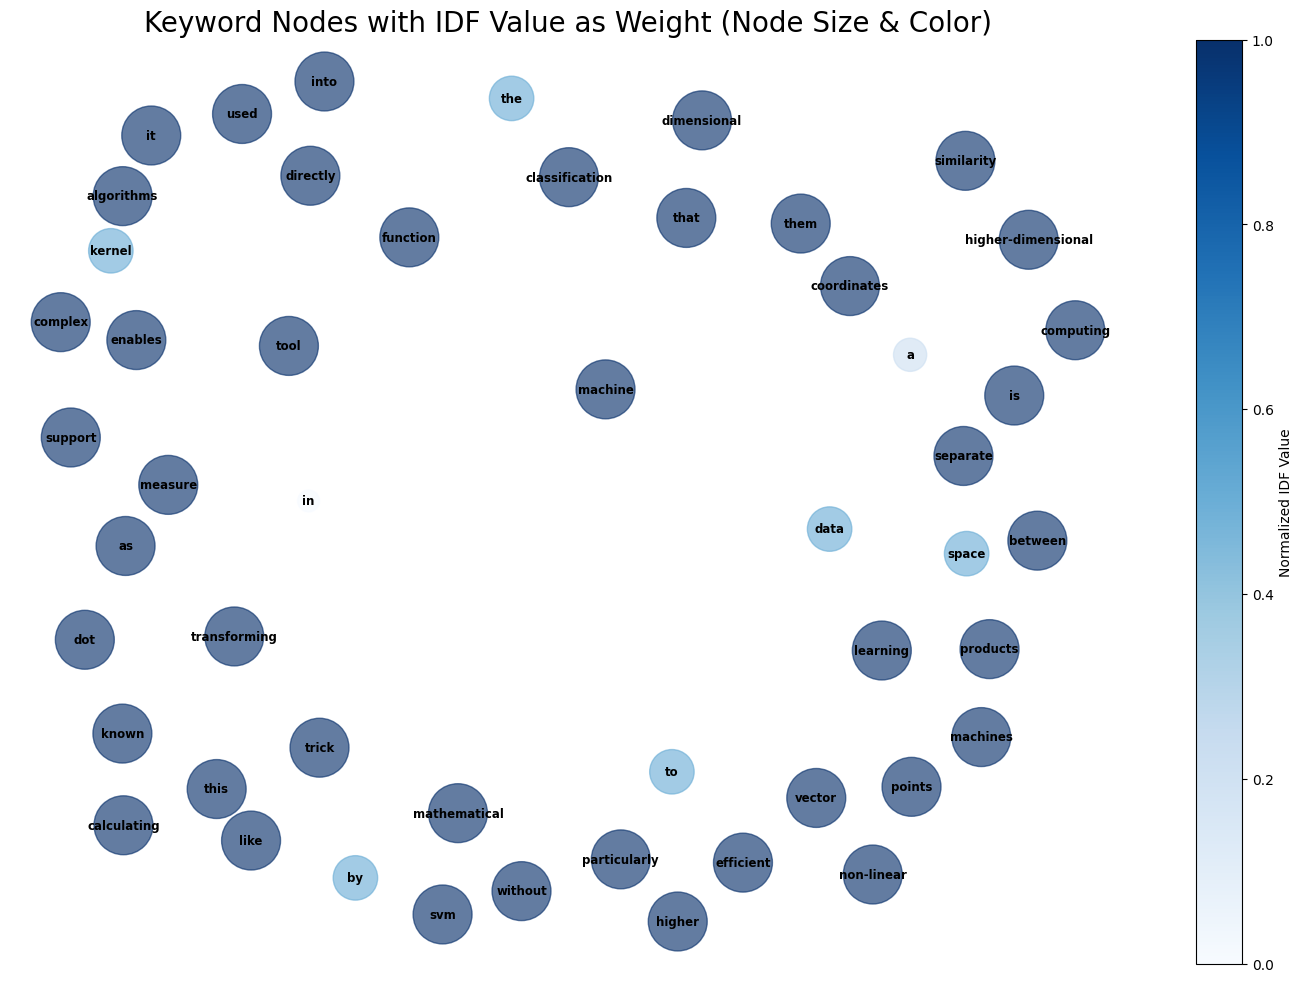

In [ ]:
graph_node(sentence)